In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 
sys.path.append('/home/cosweeney/code/Fits/')

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *
from JoCond.jocond.hgcf import *
from JoCond.jocond.myconfig import*

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.stats import gennorm, norm, t
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit

import pandas as pd
import os

plt.rcParams['axes.labelsize'] = 20


0.6777 74.71913613009617 74.71913613009617


In [2]:
# add vr, r data to binned data

def bin_pairwise_galaxy_cat(raw_file_path, save_dir, Mvirs, Mvir_bins, R_bins, rlos_bins):
    """
    Reads HDF5 galaxy catalog data, re-bins it by Mvir, R, and rlos, and saves the result.

    Parameters:
    - raw_file_path:  str, path to the raw hdf5 file
    - save_dir:       str, directory where the binned data should be saved
    - Mvirs:          list/array, the ORIGINAL mass bin keys used in the HDF5 file
                      (only used to iterate over the input HDF5 groups)
    - Mvir_bins:      array-like, NEW bin edges for Mvir — galaxies are re-assigned to
                      these bins based on their actual Mvir value
    - R_bins:         array-like, bin edges for R
    - rlos_bins:      array-like, bin edges for rlos

    Returns:
    - binned_dict: Nested dict structured as dict[Mvir_bin_idx][R_bin_idx][rlos_bin_idx][field]
    - master_df:   Full Pandas DataFrame for advanced querying
    """
    all_dfs = []

    # ------------------------------------------------------------------ #
    # 1. Read ALL groups from the HDF5 file into a single flat DataFrame  #
    # ------------------------------------------------------------------ #
    with h5.File(raw_file_path, 'r') as hdf:
        for k in range(len(Mvirs)):
            df = pd.DataFrame({
                'R':        hdf[f'R/{k}'][()],
                'rlos':     hdf[f'rlos/{k}'][()],
                'vpeclos':  hdf[f'vpeclos/{k}'][()],
                'vphyslos': hdf[f'vphyslos/{k}'][()],
                'Mvir':     hdf[f'Mvir/{k}'][()],
                'r':        hdf[f'r/{k}'][()],
                'vr':       hdf[f'vr/{k}'][()],
            })
            all_dfs.append(df)

    master_raw = pd.concat(all_dfs, ignore_index=True)

    # ------------------------------------------------------------------ #
    # 2. Re-bin on Mvir, R, and rlos using the SUPPLIED bin edges         #
    # ------------------------------------------------------------------ #
    master_raw['Mvir_bin'] = pd.cut(
        master_raw['Mvir'], bins=Mvir_bins, labels=False, include_lowest=True
    )
    master_raw['R_bin'] = pd.cut(
        master_raw['R'], bins=R_bins, labels=False, include_lowest=True
    )
    master_raw['rlos_bin'] = pd.cut(
        master_raw['rlos'], bins=rlos_bins, labels=False, include_lowest=True
    )

    # Drop anything outside any of the three sets of bin edges
    master_df = master_raw.dropna(subset=['Mvir_bin', 'R_bin', 'rlos_bin']).copy()
    master_df[['Mvir_bin', 'R_bin', 'rlos_bin']] = (
        master_df[['Mvir_bin', 'R_bin', 'rlos_bin']].astype(int)
    )

    # ------------------------------------------------------------------ #
    # 3. Generate filename and save                                        #
    # ------------------------------------------------------------------ #
    filename = (
        f"binned_"
        f"M{len(Mvir_bins)-1}_{Mvir_bins[0]:.2e}-{Mvir_bins[-1]:.2e}_"
        f"R{len(R_bins)-1}_{R_bins[0]:.1f}-{R_bins[-1]:.1f}_"
        f"rlos{len(rlos_bins)-1}_{rlos_bins[0]:.1f}-{rlos_bins[-1]:.1f}.h5"
    )
    save_path = os.path.join(save_dir, filename)

    master_df.to_hdf(save_path, key='binned_data', mode='w', format='table')
    print(f"Successfully saved binned data to: {save_path}")

    # ------------------------------------------------------------------ #
    # 4. Build nested dictionary keyed on the NEW bin indices             #
    # ------------------------------------------------------------------ #
    binned_dict = {}

    for (m_i, r_i, rlos_i), group in master_df.groupby(['Mvir_bin', 'R_bin', 'rlos_bin']):
        binned_dict.setdefault(m_i, {}).setdefault(r_i, {})[rlos_i] = {
            'vpeclos':  group['vpeclos'].values,
            'vphyslos': group['vphyslos'].values,
            'rlos':     group['rlos'].values,
            'R':        group['R'].values,
            'Mvir':     group['Mvir'].values,
            'r':        group['r'].values,
            'vr':       group['vr'].values,
        }

    return binned_dict, master_df

vel_path = '/spiff/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/r_R_rlos_vpeclos_vphyslos_data_mass_100_no_vlos_cut_lowmass.hdf5'


data_dict, df = bin_pairwise_galaxy_cat(
    raw_file_path=vel_path, 
    save_dir='/spiff/cosweeney/simulations/MDPL2/data/binned_data', 
    Mvirs=Mvirs,
    Mvir_bins=mbins2, 
    R_bins=R_edges, 
    rlos_bins=rlos_edges_dual
)

NameError: name 'Mvirs' is not defined

In [2]:

def load_pairwise_galaxy_cat(file_path):
    """
    Loads binned HDF5 galaxy catalog data saved by bin_pairwise_galaxy_cat.
    
    Parameters:
    - file_path: str, the exact path to the saved .h5 file
    
    Returns:
    - binned_dict: The reconstructed nested dictionary dict[k][R_bin_idx][rlos_bin_idx]
    - master_df: The full loaded Pandas DataFrame
    """
    # 1. Load the master DataFrame using the key we defined during saving
    master_df = pd.read_hdf(file_path, key='binned_data')
    
    # 2. Reconstruct the nested dictionary using the exact same groupby logic
    binned_dict = {}
    
    for (k, r_i, rlos_i), group in master_df.groupby(['Mvir_bin', 'R_bin', 'rlos_bin']):
        if k not in binned_dict:
            binned_dict[k] = {}
        if r_i not in binned_dict[k]:
            binned_dict[k][r_i] = {}
            
        binned_dict[k][r_i][rlos_i] = {
            'vpeclos':  group['vpeclos'].values,
            'vphyslos': group['vphyslos'].values,
            'rlos':     group['rlos'].values,
            'R':        group['R'].values,
            'Mvir':     group['Mvir'].values,
            'r':        group['r'].values,
            'vr':       group['vr'].values,
        }
        
    return binned_dict, master_df

vel_path = '/spiff/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/r_R_rlos_vpeclos_vphyslos_data_mass_100_no_vlos_cut_lowmass.hdf5'

# Load data
data_dict, df = load_pairwise_galaxy_cat('/spiff/cosweeney/simulations/MDPL2/data/binned_data/binned_M10_8.00e+13-8.00e+14_R25_5.0-30.0_rlos120_-60.0-60.0.h5')

In [ ]:
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins, just out to 30/69 for now
R_edges = np.linspace(5, 30, (30-5)+1)
R_cens = (R_edges[1:]+R_edges[:-1])/2.0 

rlos_edges = np.linspace(0, 60, (60-0)+1)
rlos_cens = (rlos_edges[1:]+rlos_edges[:-1])/2.0 

rlos_edges_dual = np.linspace(-60, 60, (60-(-60))+1)
rlos_cens_dual = (rlos_edges_dual[1:]+rlos_edges_dual[:-1])/2.0 

# update Mass bins
Mvir = np.array(df['Mvir']) # Host halo virial mass

mbins2 = np.logspace(np.log10(8e13), np.log10(8e14), 10+1)

Mvirs2=[]
for i in range(len(mbins2)-1):
    mmask = (Mvir>=mbins2[i])&(Mvir<=mbins2[i+1])
    Ms = Mvir[mmask] 

    Mvirs2.append(np.median(Ms))
Mvirs2=np.array(Mvirs2)

massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


In [4]:
def skewed_t_pdf(x, xi, omega, alpha, nu):
    """
    Azzalini & Capitanio skewed t-distribution PDF
    
    Parameters:
    xi: location parameter
    omega: scale parameter (> 0)
    alpha: skewness parameter
    nu: degrees of freedom (> 0)
    """
    # Standardize
    z = (x - xi) / omega
    
    # Student's t PDF
    t_pdf = t.pdf(z, df=nu)
    
    # Student's t CDF with modified argument
    t_cdf = t.cdf(alpha * z * np.sqrt((nu + 1) / (nu + z**2)), df=nu + 1)
    
    # Skewed t PDF
    pdf = (2 / omega) * t_pdf * t_cdf
    
    return pdf

# compute <vr|r>
import numpy as np
from scipy.stats import binned_statistic

# Define 101 contiguous bin edges (which creates 100 bins)
r_edges_LS = np.linspace(5, 65, 101) 
r_cens_LS = (r_edges_LS[1:] + r_edges_LS[:-1]) / 2.0
mean_vr_r = np.zeros((len(Mvirs2), len(r_edges_LS)-1))

for k in range(len(Mvirs2)):
    # Filter for the current Mvir_bin
    mask = (df['Mvir_bin'] == k)
    
    # binned_statistic handles the grouping and the mean calculation instantly
    means, edges, bin_numbers = binned_statistic(
        x=df.loc[mask, 'r'], 
        values=df.loc[mask, 'vr'], 
        statistic='mean', 
        bins=r_edges_LS
    )
    
    mean_vr_r[k, :] = means


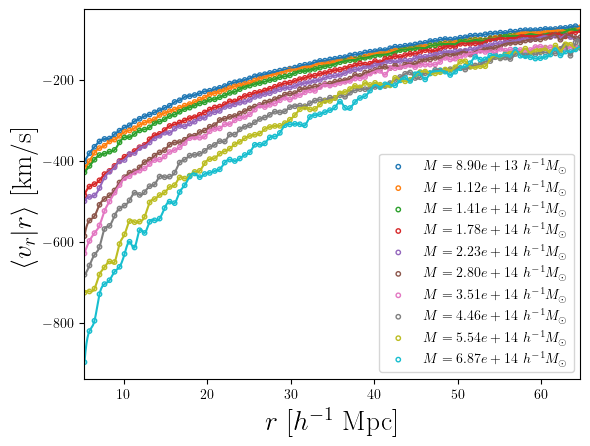

In [5]:
from scipy.interpolate import RectBivariateSpline


RBinterp = RectBivariateSpline(np.log10(Mvirs2), r_cens_LS, mean_vr_r, kx=3, ky=3) 

for k in range(len(Mvirs2)):

    plt.scatter(r_cens_LS, mean_vr_r[k], edgecolors=f'C{k}', marker='o', s=10, facecolors='none', label=rf'$M={Mvirs2[k]:.2e}\ h^{{-1}}M_\odot$')

    #mask = (r_cens_LS > 5) & (~np.isnan(mean_vr_r[k]))

    r_fine = np.linspace(r_cens_LS.min(), r_cens_LS.max(), 1000)

    mean_vr_M = RBinterp(np.log10(Mvirs2[k]), r_fine).squeeze()

    plt.plot(r_fine, mean_vr_M, color=f'C{k}', ls='-')

    #plt.ylim((-1000, 100))
    #plt.ylim((-100, 1000))
    #plt.yscale('log') 
    #plt.xscale('log')
    plt.legend()
    plt.margins(x=0)
    plt.ylabel(r"$\langle v_r|r\rangle$ [km/s]", fontsize=20)
    plt.xlabel(r"$r \ [h^{-1}$ Mpc]", fontsize=20)

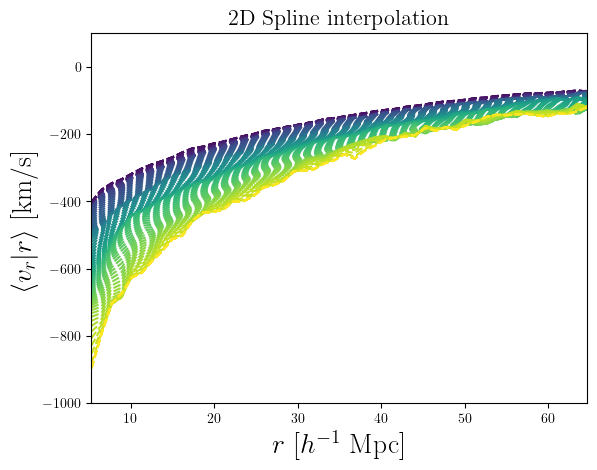

In [6]:
M_test = np.logspace(np.log10(mbins2[0]), np.log10(mbins2[-1]), 100)

cmap = plt.get_cmap('viridis').resampled(len(M_test))
colors = [cmap(i) for i in range(len(M_test))]

for k in range(len(M_test)):
    r_fine = np.linspace(r_cens_LS.min(), r_cens_LS.max())

    mean_vr_M = RBinterp(np.log10(M_test[k]), r_fine).squeeze()

    plt.plot(r_fine, mean_vr_M, color=colors[k], ls='--')

    plt.ylim((-1000, 100))
    plt.margins(x=0)
    plt.ylabel(r"$\langle v_r|r\rangle$ [km/s]", fontsize=20)
    plt.xlabel(r"$r \ [h^{-1}$ Mpc]", fontsize=20)
    plt.title("2D Spline interpolation", fontsize=16)


In [7]:
# save interpolator
save_path = '/spiff/cosweeney/simulations/MDPL2/data/models'

np.savez(save_path+'vr_mean_r_RBS_data.npz', 
         tx=RBinterp.tck[0], 
         ty=RBinterp.tck[1], 
         c=RBinterp.tck[2], 
         kx=RBinterp.degrees[0],
         ky=RBinterp.degrees[1])

In [ ]:
save_path = '/spiff/cosweeney/simulations/MDPL2/data/models'

data = np.load(save_path+'vr_mean_r_RBS_data.npz')
from scipy.interpolate import RectBivariateSpline

# Re-initialize the object (we use a dummy grid then overwrite)
RBinterp = RectBivariateSpline.__new__(RectBivariateSpline)
RBinterp.tck = (data['tx'], data['ty'], data['c'])
RBinterp.degrees = (data['kx'], data['ky'])

In [7]:
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'


sigma_h_vlos = np.zeros(len(Mvirs2))

with h5.File(halo_path, 'r') as hcat:

    for k, M in enumerate(Mvirs2):
        hm_cut = (hcat['mvir'][()] >= mbins2[k])&(hcat['mvir'][()] <= mbins2[k+1])

        #print(np.sum(hm_cut))

        hvel = np.array([
            hcat['vx'][()][hm_cut],
            hcat['vy'][()][hm_cut], 
            hcat['vz'][()][hm_cut],
        ]).T

        sigma_h_vlos[k] = np.std(hvel[:, 2])

gal_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/UM_full_gal_table.hdf5'

box_length = 1000 #Mpc/h, MDPL2 box side length

sigma_g_vlos = np.zeros(len(Mvirs2))

with h5.File(gal_path, 'r') as gcat:
    for k in range(len(Mvirs2)):
        #print(gcat.keys())
        sm_cut = gcat['sm'][()] > 1e10
        m_cut = (gcat['m'][()] >= mbins2[k])&(gcat['m'][()] < mbins2[k+1])

        mask = sm_cut & m_cut

        gvel = np.array([
            gcat['pos'][:, 3][()][mask],
            gcat['pos'][:, 4][()][mask], 
            gcat['pos'][:, 5][()][mask],
        ]).T

        sigma_g_vlos[k] = np.std(gvel[:, 2])

In [8]:
# Plot measured dispersions, compare to \sigma_v resulting from latest fits

meas_sigv = np.zeros((len(Mvirs2), len(R_cens), len(rlos_cens)))

for k in range(len(Mvirs2)):
    for j in range(len(R_cens)):
        for i in range(len(rlos_cens)):
            std = np.std(data_dict[k][j][i+59]['vpeclos'])
            meas_sigv[k, j, i] = std

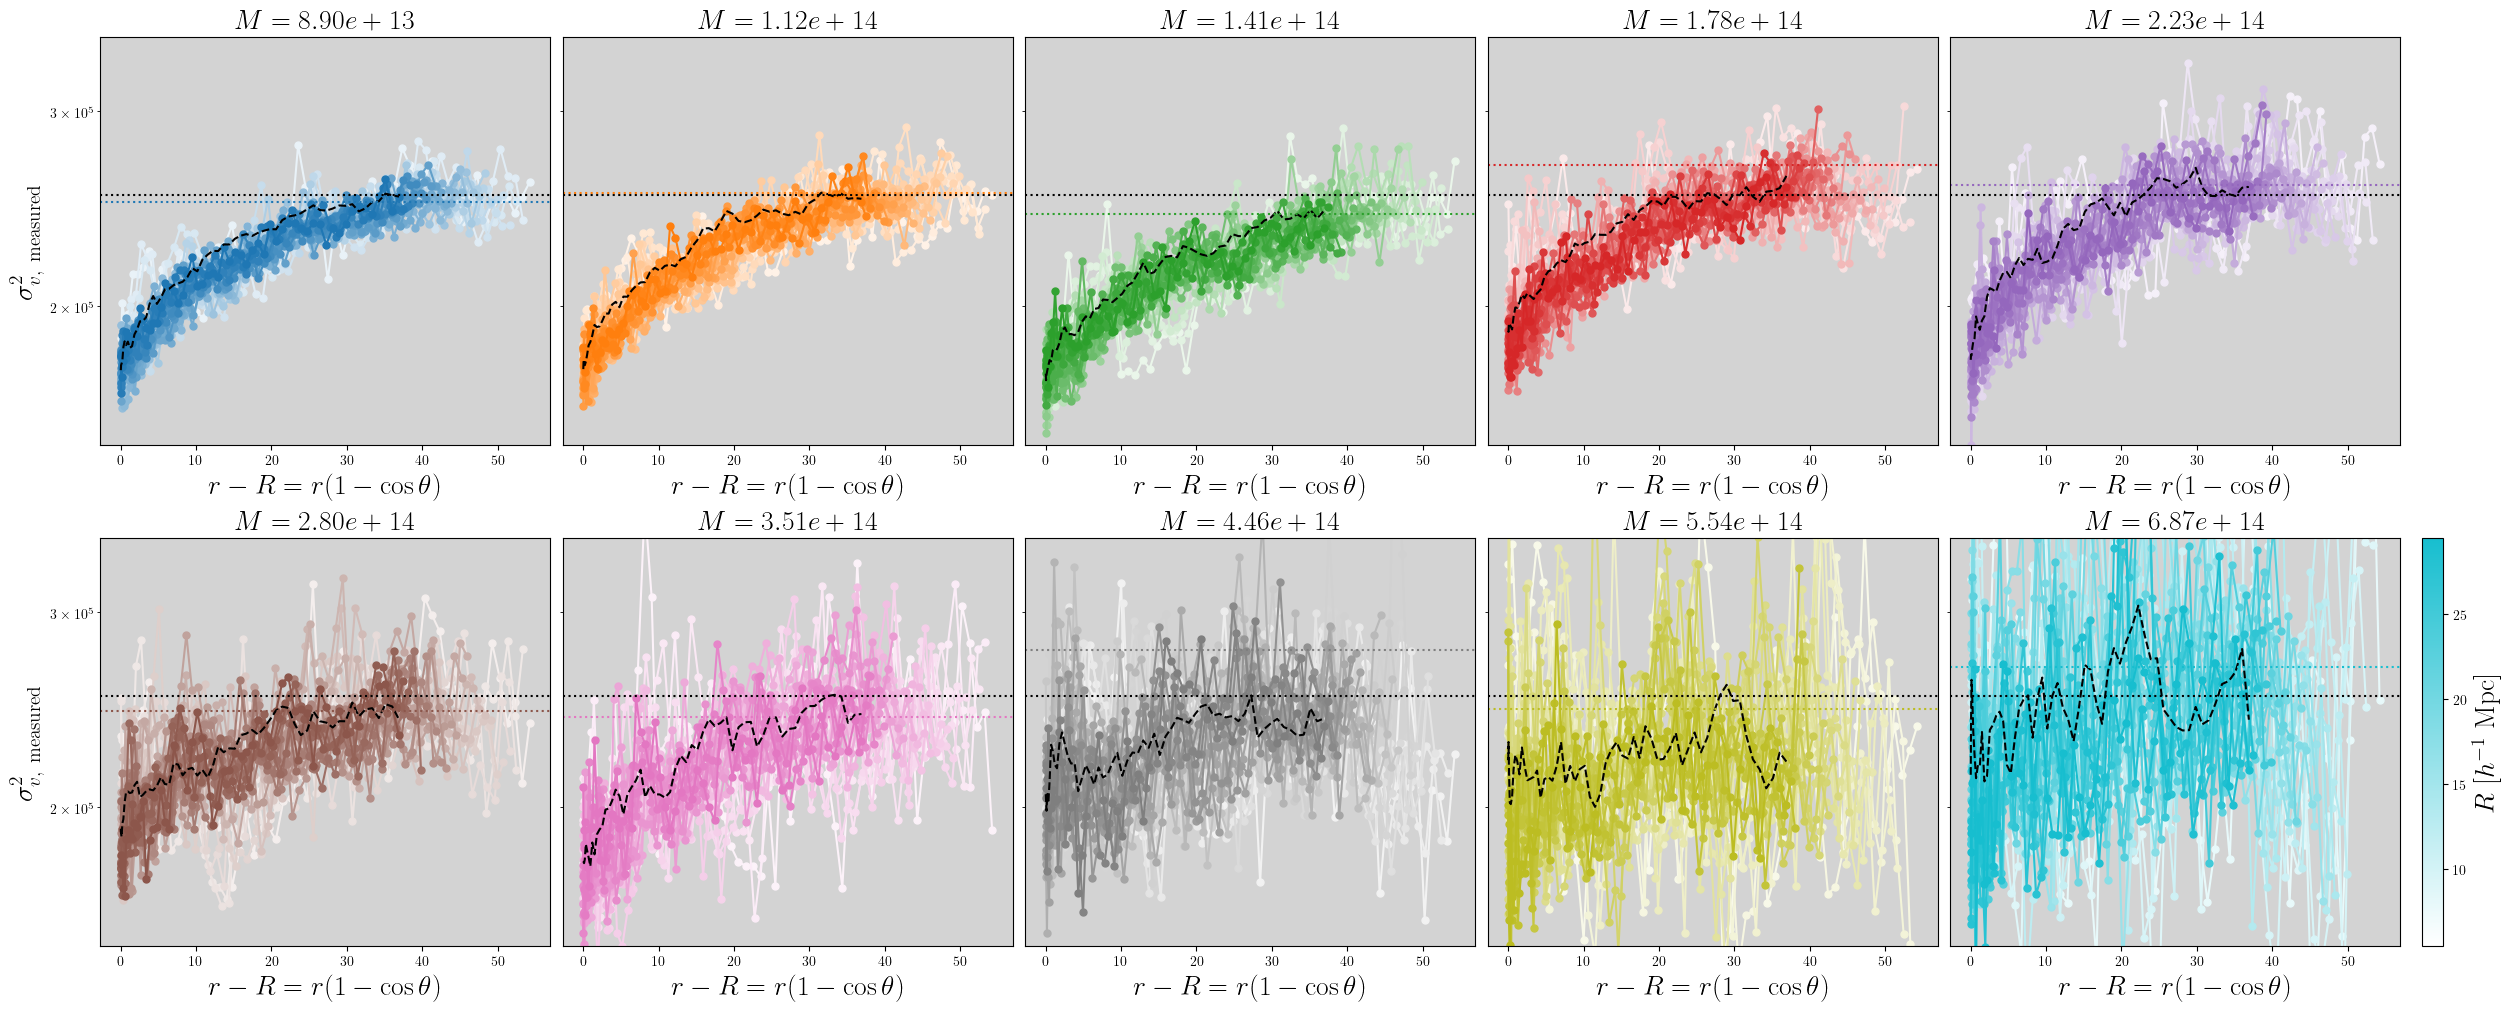

In [9]:
import math
import matplotlib.colors as mcolors
from scipy.optimize import minimize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

ncols = math.ceil(len(Mvirs2) / 2)   # row 1 length; row 2 = len(Mvirs2)//2
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(25, 10), layout='constrained', sharey=True)
ax = axes.flatten()                    # index linearly: ax[k] as before

ys     = meas_sigv**2
colors = plt.cm.tab10.colors
nR     = len(R_cens)
nlos   = len(rlos_cens)

rho_x_M = np.zeros((len(Mvirs2), nR, nlos))

for k in range(len(Mvirs2)):
    cmap  = mcolors.LinearSegmentedColormap.from_list(f"cmap_{k}", ['white', colors[k]])
    cmaps = cmap(np.linspace(0.1, 1.0, nR))
    for j in range(nR):
        R    = R_cens[j]
        rlos = rlos_cens
        r    = np.sqrt(R**2 + rlos**2)
        ax[k].plot(r - R, ys[k, j], c=cmaps[j], marker='o', markersize=5)
        ax[k].set_xlabel(r"$r-R = r(1-\cos\theta)$", fontsize=20)
        ax[k].set_facecolor('lightgray')
        ax[k].set_yscale('log')
        ax[k].set_ylim((1.5e5, 3.5e5))
        ax[k].set_title(rf"$M={Mvirs2[k]:.2e}$", fontsize=20)

        rho_x_M[k, j] = 1 - ys[k, j]/(2*(355)**2)
    
    ax[k].plot(r - R, np.mean(ys[k], axis=0), c='k', ls='--')
    ax[k].axhline(2*(355)**2, c='k', ls=':')
    ax[k].axhline(2*sigma_h_vlos[k]**2, c=f'C{k}', ls=':')

# Hide unused axes when len(Mvirs2) is odd
for k in range(len(Mvirs2), nrows * ncols):
    ax[k].set_visible(False)

# ylabel for the first column of each row
axes[0, 0].set_ylabel(r'$\sigma_{v, \ \rm measured}^2$', fontsize=20)
axes[1, 0].set_ylabel(r'$\sigma_{v, \ \rm measured}^2$', fontsize=20)

Norm = Normalize(vmin=min(R_cens), vmax=max(R_cens))
sm   = ScalarMappable(norm=Norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[len(Mvirs2) - 1])  # attach to last used axis
cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

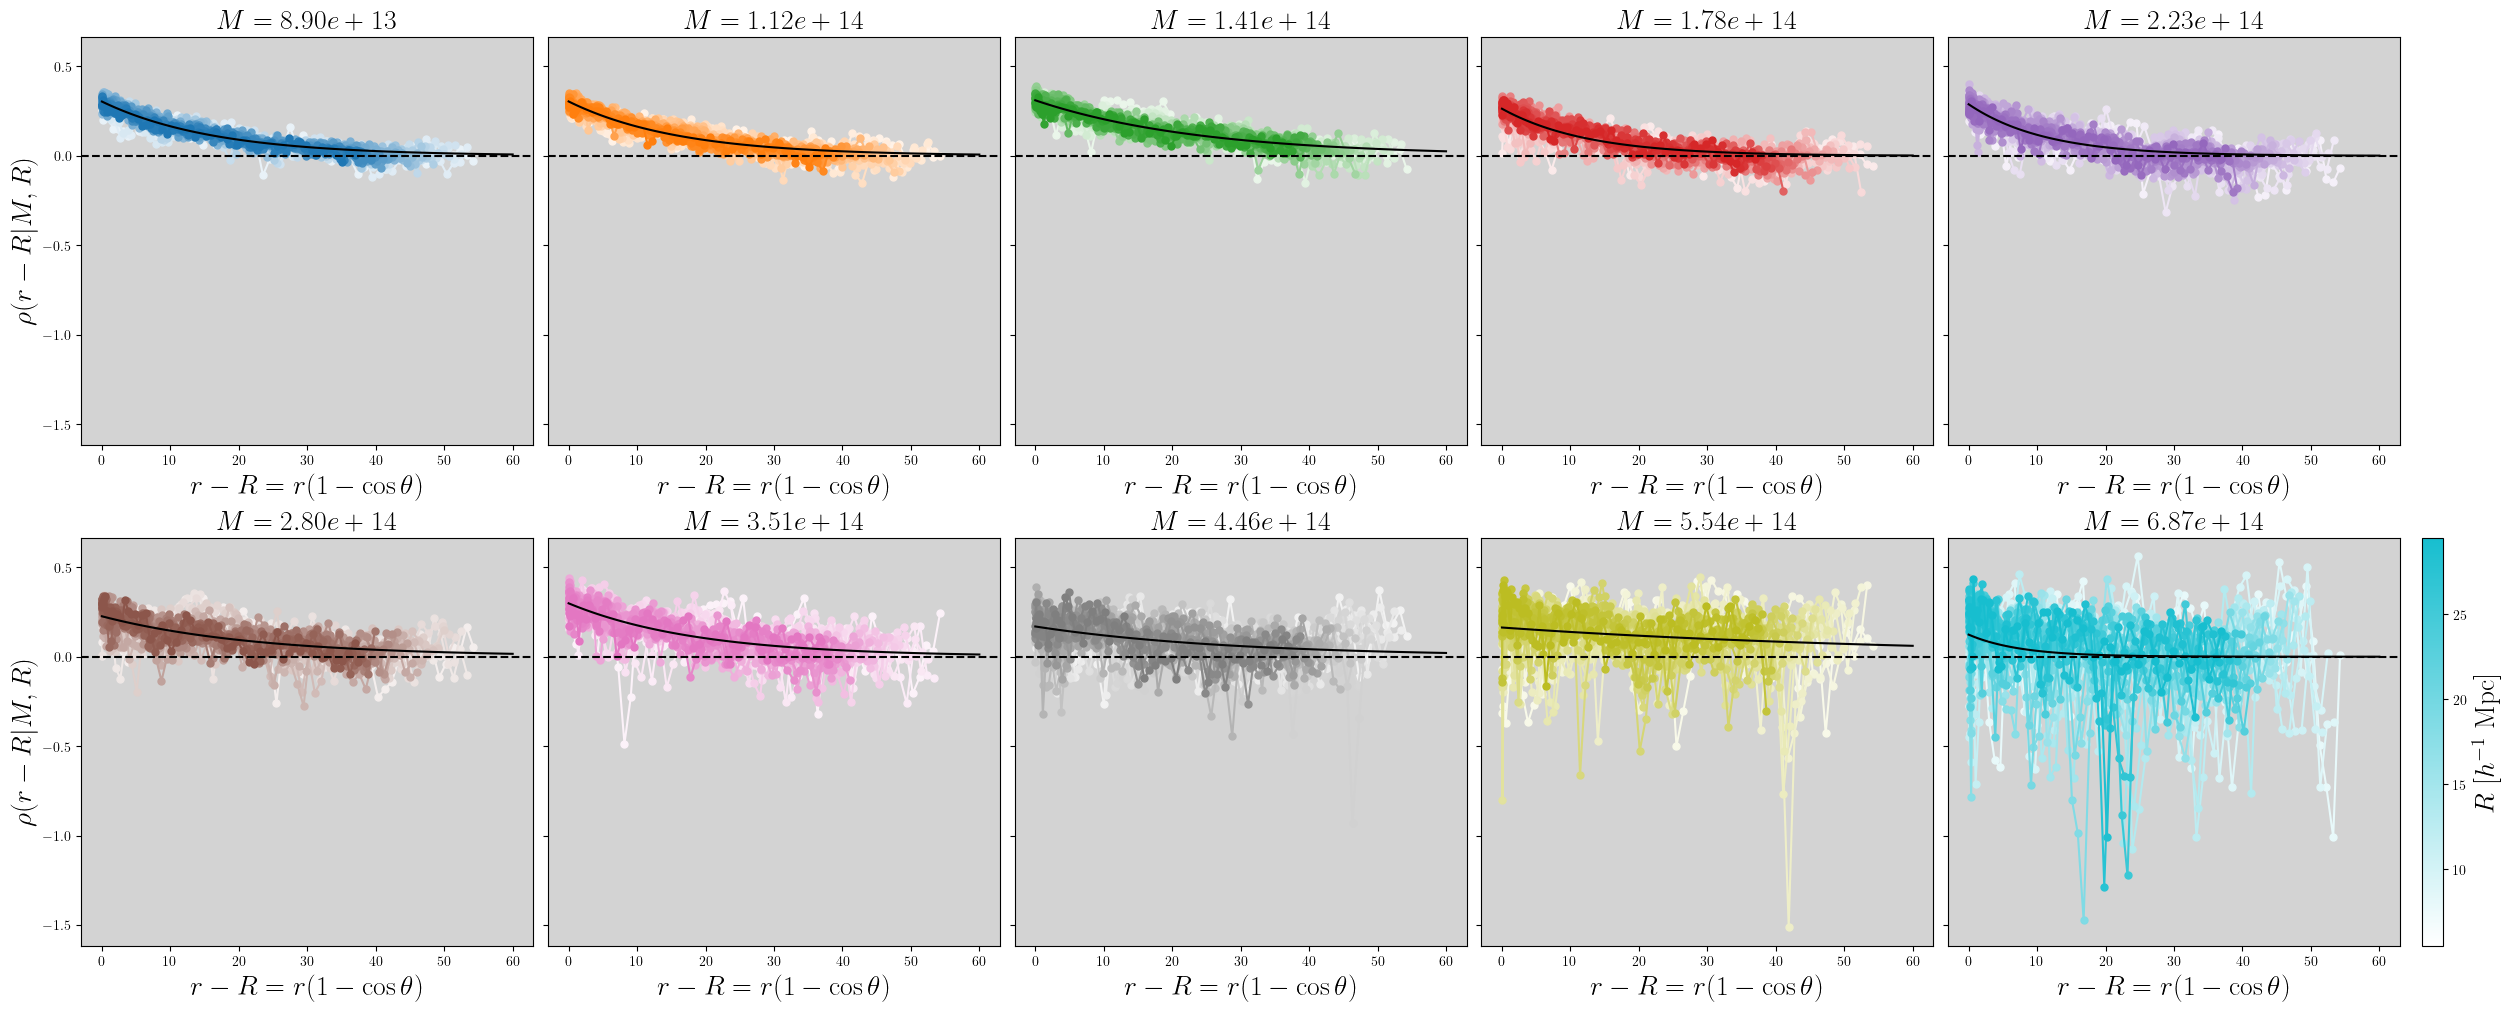

In [10]:
fig, axes = plt.subplots(nrows, ncols, figsize=(25, 10), layout='constrained', sharey=True)
ax = axes.flatten()                    # index linearly: ax[k] as before

ys     = meas_sigv**2
colors = plt.cm.tab10.colors
nR     = len(R_cens)
nlos   = len(rlos_cens)

r_grid = np.sqrt(R_cens[:, None]**2 + rlos_cens[None, :]**2)
x_grid = r_grid - R_cens[:, None]

xs = np.linspace(0, 60, 100)

sig_rho = np.zeros((len(Mvirs2), 2))

a_rho = np.zeros(len(Mvirs2))

for k in range(len(Mvirs2)):
    cmap  = mcolors.LinearSegmentedColormap.from_list(f"cmap_{k}", ['white', colors[k]])
    cmaps = cmap(np.linspace(0.1, 1.0, nR))
    for j in range(nR):
        R    = R_cens[j]
        rlos = rlos_cens
        r    = np.sqrt(R**2 + rlos**2)
        ax[k].plot(r - R, rho_x_M[k, j], c=cmaps[j], marker='o', markersize=5)
        ax[k].set_xlabel(r"$r-R = r(1-\cos\theta)$", fontsize=20)
        ax[k].set_facecolor('lightgray')
        #ax[k].set_yscale('log')
        #ax[k].set_ylim((1.5e5, 3.5e5))
        ax[k].set_title(rf"$M={Mvirs2[k]:.2e}$", fontsize=20)

    ax[k].axhline(0, c='k', ls='--')

    exp_fcn = lambda x, a, s: a*np.exp(-x/s)
    p, c = curve_fit(exp_fcn, x_grid.flatten(), rho_x_M[k].flatten(), p0=[2, 10], maxfev=10_000)
    sig_rho[k] = p
    ax[k].plot(xs, exp_fcn(xs, *p), c='k', ls='-')


    p, c = curve_fit(lambda x, a: exp_fcn(x, a, sig_rho[0, 1]), x_grid.flatten(), rho_x_M[k].flatten(), p0=[2], maxfev=10_000)
    a_rho[k] = p

# Hide unused axes when len(Mvirs2) is odd
for k in range(len(Mvirs2), nrows * ncols):
    ax[k].set_visible(False)

# ylabel for the first column of each row
axes[0, 0].set_ylabel(r'$\rho(r-R|M, R)$', fontsize=20)
axes[1, 0].set_ylabel(r'$\rho(r-R|M, R)$', fontsize=20)

Norm = Normalize(vmin=min(R_cens), vmax=max(R_cens))
sm   = ScalarMappable(norm=Norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[len(Mvirs2) - 1])  # attach to last used axis
cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

In [11]:

rho_pars = np.array([-0.03055477,  0.34374933, 16.46892317])#np.array([ap_pars[0], ap_pars[1], sig_rho[0, 1]])

def rho_mod(x, M, pars):
    am, ab, s = pars
    a = line(M/1e14, am, ab)
    return a*np.exp(-x/s)

def sig_vm(x, M, pars):
    rho = rho_mod(x, M, pars)
    s_0 = 355

    return np.sqrt(2*s_0**2 * (1 - rho))

In [12]:
# load data
save_path = '/spiff/cosweeney/simulations/MDPL2/data/'

STpars = np.load(save_path+'M10_R_rlos_30_60_STpars.npy')

STerrs = np.load(save_path+'M10_R_rlos_30_60_STerrs.npy')

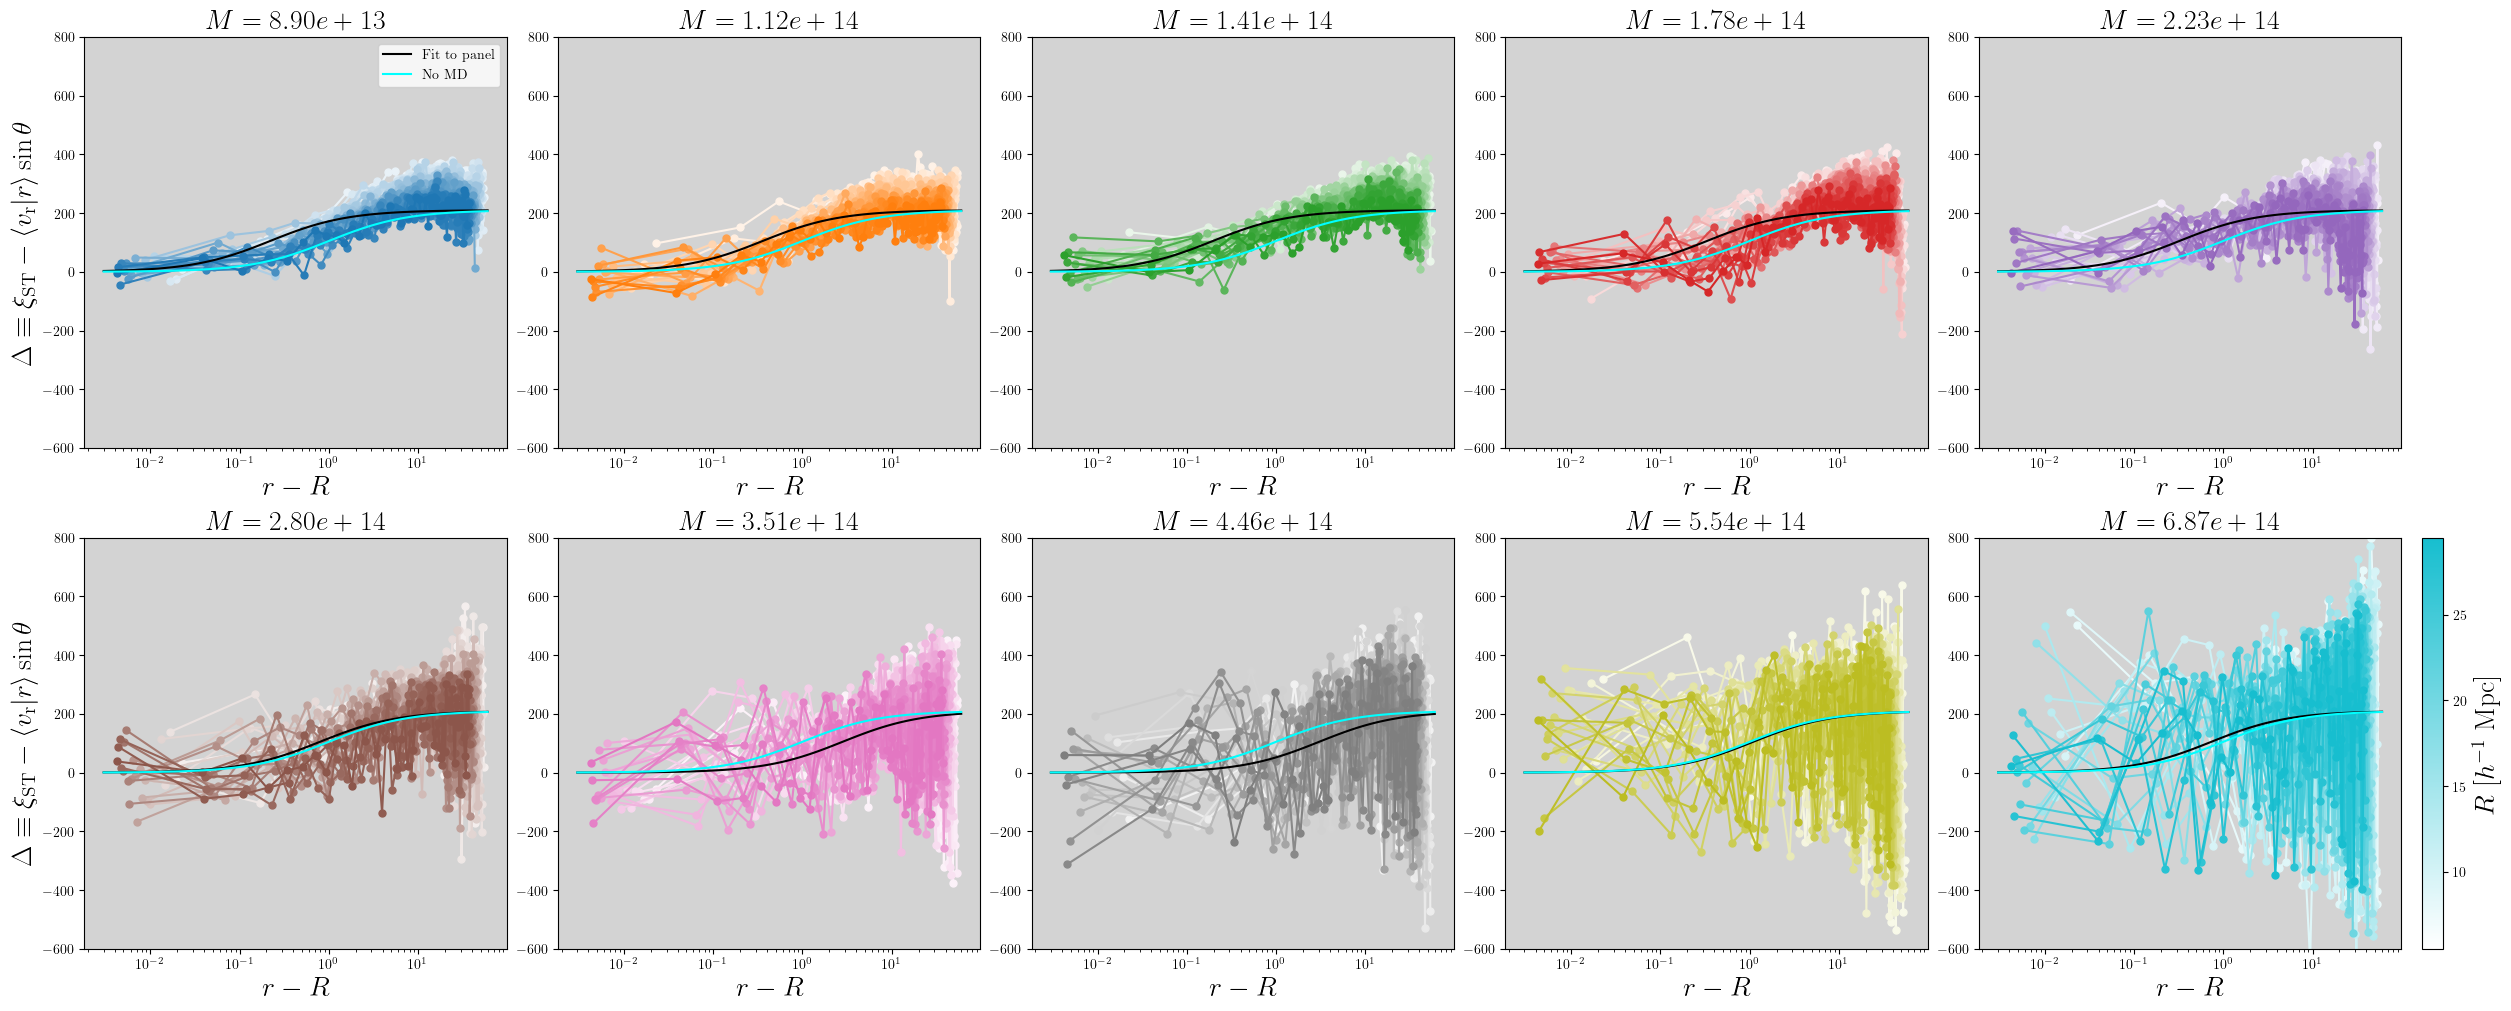

In [15]:
import math
import matplotlib.colors as mcolors
from scipy.optimize import minimize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

ncols = math.ceil(len(Mvirs2) / 2)   # row 1 length; row 2 = len(Mvirs2)//2
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(25, 10), layout='constrained', sharey=False)
ax = axes.flatten()                    # index linearly: ax[k] as before

nu = 6
xis = STpars[:, :, :, 0]
xi_e = STerrs[:, :, :, 0]
alphas = STpars[:, :, :, 2]
omegas = STpars[:, :, :, 1]
deltas = alphas / np.sqrt(1+alphas**2)

betanu = np.sqrt(nu/np.pi) * scipy.special.gamma((nu - 1)/2)/scipy.special.gamma((nu)/2) 
sigmaz = np.sqrt(nu/(nu-2) - (betanu*deltas)**2)

sigma_v = omegas * sigmaz

gamma_v = (betanu*deltas)/sigmaz**3 * ( nu*(3-deltas**2)/(nu-3) - 3*nu/(nu-2) + 2*(betanu*deltas)**2 )

#ys     = meas_skew
colors = plt.cm.tab10.colors
nR     = len(R_cens)
nlos   = len(rlos_cens)

Deltas = np.zeros((len(Mvirs2), nR, nlos))

r_grid = np.sqrt(R_cens[:, None]**2 + rlos_cens[None, :]**2)
x_grid = r_grid - R_cens[:, None]

xs = np.logspace(np.log10(3e-3), np.log10(60), 100)

delta_pars = np.zeros((len(Mvirs2), 1))
delta_errs = np.zeros((len(Mvirs2), 1))

mins = np.zeros(len(Mvirs2))

p00 = [1]
p01  = []

for k in range(len(Mvirs2)):
    cmap  = mcolors.LinearSegmentedColormap.from_list(f"cmap_{k}", ['white', colors[k]])
    cmaps = cmap(np.linspace(0.1, 1.0, nR))
    for j in range(nR):
        R    = R_cens[j]
        rlos = rlos_cens
        r    = np.sqrt(R**2 + rlos**2)
        sin = rlos / r

        mode = RBinterp(np.log10(Mvirs2[k]), r).squeeze()*sin 

        ys = -(mode - xis[k, j])#/meas_sigv[k, j]
        Deltas[k, j] = ys

        mask = np.abs(alphas[k, j]) < 10

        #print(np.mean(ys[mask][(r-R)[mask] > 10]))

        ax[k].plot((r-R)[mask], ys[mask], c=cmaps[j], marker='o', markersize=5)
        ax[k].set_xlabel(r"$r-R$", fontsize=20)
        ax[k].set_facecolor('lightgray')
        ax[k].set_xscale('log')
        ax[k].set_title(rf"$M={Mvirs2[k]:.2e}$", fontsize=20)
        ax[k].set_ylim((-600, 800))
    #ax[k].axhline(np.mean(Deltas[k, :, :3]), c='g', ls='--')
    #print(np.mean(Deltas[k, :, :3]))
    
    # p, c = curve_fit(lambda x, x_0, x_t: Delta(x, x_0, x_t, 170), x_grid.flatten(), Deltas[k].flatten(), p0=[0.1, 15], bounds=[(0.001, 0.001), (np.inf, np.inf)],  maxfev=10_000)
    # #delta_pars[k] = p
    # ax[k].plot(xs, Delta(xs, *p, 170), c='k', ls='-')
    #ax[k].axvline(p[0], c='k', ls='--')
    #ax[k].axvline(p[1], c='k', ls='--')

    # p, c = curve_fit(lambda x, C: 170*x/(1+x)+C, x_grid.flatten(), Deltas[k].flatten(), p0=[-50],  maxfev=10_000)

    #mins[k] = np.min(Deltas[k, :, 0])

    p, c = curve_fit(lambda x, sig: 210*x/(sig+x), x_grid.flatten(), Deltas[k].flatten(), p0=[1],  maxfev=10_000)
    delta_pars[k] = p
    delta_errs[k] = np.sqrt(np.diag(c))
    ax[k].plot(xs,  210*xs/(p+xs), c='k', ls='-', label='Fit to panel')

    # if k == 0:
    #     p0 = p00
    # else:
    #     p0 = p01

    # p, c = curve_fit(lambda x, a: 170*x/(a+x), x_grid.flatten(), Deltas[k].flatten(),  p0=p0, bounds=[(0), (np.inf)],  maxfev=10_000)
    # delta_pars[k] = p
    # delta_errs[k] = np.sqrt(np.diag(c))
    # p01 = p

    # ax[k].plot(xs,  170*xs/(p+xs), c='k', ls='-', label='Fit to panel')
    ax[k].plot(xs,  210*xs/(1+xs), c='cyan', ls='-', label='No MD')

    #da = plawc(Mvirs2[k]/1e14, *delta_mpars[0][0])
    #ax[k].plot(xs,  210*xs/(da+xs), c='k', ls='--', label='smooth model')

    if k == 0:
        ax[k].legend(fontsize=10)

# Hide unused axes when len(Mvirs2) is odd
for k in range(len(Mvirs2), nrows * ncols):
    ax[k].set_visible(False)

# ylabel for the first column of each row
axes[0, 0].set_ylabel(r'$\Delta\equiv\xi_{\rm ST}-\langle v_{\rm r}|r\rangle\sin\theta$', fontsize=20)
axes[1, 0].set_ylabel(r'$\Delta\equiv\xi_{\rm ST}-\langle v_{\rm r}|r\rangle\sin\theta$', fontsize=20)

Norm = Normalize(vmin=min(R_cens), vmax=max(R_cens))
sm   = ScalarMappable(norm=Norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[len(Mvirs2) - 1])  # attach to last used axis
cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

In [16]:
def plot_dependence(x_quant, y_quants, y_errs, xlabel, ylabels, fitfuncs=None, pivot=1, p0=None, masks=None):
    ncol = y_quants.shape[-1]

    fig, axes = plt.subplots(1, ncol, figsize=(ncol*5, 5), layout='constrained')

    if y_quants.shape[-1] > 1:
        pars = []

        for i, ax in enumerate(axes):
            ax.errorbar(x_quant, y_quants[:, i], y_errs[:, i], fmt='o-')
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabels[i])

            if fitfuncs:
                p, c = curve_fit(fitfuncs[i], x_quant[masks[i]]/pivot, y_quants[:, i][masks[i]], sigma=y_errs[:, i][masks[i]], absolute_sigma=False, maxfev=10_000)

                xs = np.linspace(x_quant[0]-0.1*x_quant[0], x_quant[-1]+0.1*x_quant[-1], 100)
                ax.plot(xs, fitfuncs[i](xs/pivot, *p))

                pars.append(p)
    else:
        pars = []

        i = 0
        axes.errorbar(x_quant, y_quants[:, i], y_errs[:, i], fmt='o-')
        axes.set_xlabel(xlabel)
        axes.set_ylabel(ylabels[i])

        if fitfuncs:
            p, c = curve_fit(fitfuncs[i], x_quant[masks[i]]/pivot, y_quants[:, i][masks[i]], sigma=y_errs[:, i][masks[i]], p0=p0, absolute_sigma=False, maxfev=10_000)

            xs = np.linspace(x_quant[0]-0.1*x_quant[0], x_quant[-1]+0.1*x_quant[-1], 100)
            axes.plot(xs, fitfuncs[i](xs/pivot, *p))

            pars.append(p)
    
    if fitfuncs:
        return fig, axes, pars
    else:

        return fig, axes

(0.0, 5.0)

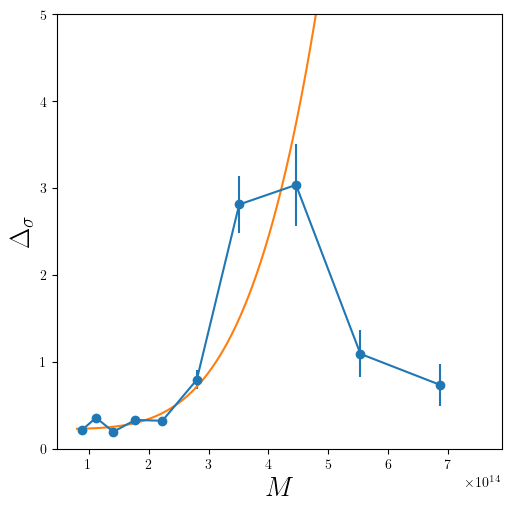

In [17]:
fig, ax, delta_mpars = plot_dependence(Mvirs2, delta_pars, delta_errs, r'$M$', [r'$\Delta_\sigma$'], [plawc], 1e14, [0.5, 4, 0], [Mvirs2<Mvirs2[-2]])
ax.set_ylim((0, 5))


In [21]:
#delta_mpars = delta_mpars[0]
delta_mpars = np.array([0.00607357, 4.25343725, 0.22794126])
print(delta_mpars)

def Delta(x, M, pars):
    a_p, a_s, a_c = pars

    M_p = 1e14

    A = 170
    a = plawc(M/M_p, a_p, a_s, a_c)

    D = A*x/(a+x)

    return D

def vlos_mean(R, rlos, M):
    r    = np.sqrt(R**2 + rlos**2)
    sin = rlos / r

    mode = RBinterp(np.log10(M), r).squeeze()*sin 

    return mode

[0.00607357 4.25343725 0.22794126]


In [27]:
import numpy as np
from scipy.stats import t as student_t
from scipy.special import gamma
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d


class SkewTMeanInterpolator:
    """
    Pre-computes the relationship between (Delta_mean / sigma_v) and (omega, alpha)
    for a Skew-T distribution using the exact algebraic mean.
    """
    def __init__(self, nu=6, alpha_bounds=(-15, 15), pts=1000):
        self.nu = nu
        
        # We can increase 'pts' since this is now an instantaneous vectorized calculation
        alphas = np.linspace(alpha_bounds[0], alpha_bounds[1], pts)
        
        # 1. Delta coefficient for Azzalini Skew-T
        delta = alphas / np.sqrt(1 + alphas**2)
        
        # 2. Exact Mean of standard Skew-T (xi=0, omega=1)
        # mu_z = delta * sqrt(nu / pi) * [Gamma((nu - 1) / 2) / Gamma(nu / 2)]
        gamma_factor = gamma((nu - 1) / 2) / gamma(nu / 2)
        mu_z = delta * np.sqrt(nu / np.pi) * gamma_factor
        
        # 3. Exact Standard Deviation of standard Skew-T
        var_z = (nu / (nu - 2)) - mu_z**2
        sig_z = np.sqrt(var_z)
        
        # 4. Ratio R = Delta_mean / sigma_v for standard distribution
        # Assuming Delta_mean = xi - mean = 0 - mu_z = -mu_z
        R_vals = -mu_z / sig_z
        
        # interp1d requires the x-array (R_vals) to be strictly monotonically increasing.
        # As alpha increases, R_vals strictly decreases, so we must reverse the arrays.
        if R_vals[-1] < R_vals[0]:
            valid_R = R_vals[::-1]
            valid_alphas = alphas[::-1]
        else:
            valid_R = R_vals
            valid_alphas = alphas
            
        # Interpolator 1: Ratio -> alpha (Upgraded to cubic for smooth analytical data)
        self.R_to_alpha = interp1d(valid_R, valid_alphas, kind='cubic', 
                                   bounds_error=False, 
                                   fill_value=(valid_alphas[0], valid_alphas[-1]))
        
        # Interpolator 2: alpha -> standard deviation
        self.alpha_to_sigZ = interp1d(alphas, sig_z, kind='cubic', 
                                      bounds_error=False, 
                                      fill_value=(sig_z[0], sig_z[-1]))

    def get_skew_params(self, delta_mean, sig_v):
        """Maps physical parameters (Delta_mean, sigma_v) to Skew-T parameters (omega, alpha)"""
        ratio = delta_mean / sig_v
        alpha = self.R_to_alpha(ratio)
        sig_z = self.alpha_to_sigZ(alpha)
        omega = sig_v / sig_z
        return omega, alpha
    
# Instantiate this globally so it isn't rebuilt on every function call
skew_interp = SkewTMeanInterpolator(nu=6)

def Pv_R_rlos(v, R, rlos, M, pars_delta=delta_mpars, pars_sig=rho_pars):
    """
    Evaluates P(v | R, rlos, M) modeled as a Skew-T distribution.
    """
    # 1. Coordinate transformations
    r = np.sqrt(R**2 + rlos**2)
    x = r - R
    
    # 2. Evaluate physical quantities via your models
    mu = vlos_mean(R, rlos, M)
    sig_v = sig_vm(x, M, pars_sig)
    
    # Enforce symmetry: Delta flips sign when rlos is negative
    sign_rlos = np.sign(rlos)
    delta_val = Delta(x, M, pars_delta) * (sign_rlos if sign_rlos != 0 else 1.0)
    
    # 3. Interpolate standard Skew-T parameters
    omega, alpha = skew_interp.get_skew_params(delta_val, sig_v)
    
    # 4. Location parameter is purely algebraic
    xi = mu + delta_val
    
    # 5. Evaluate Skew-T PDF
    nu = skew_interp.nu
    z = (v - xi) / omega
    
    # Azzalini's Skew-T formulation: 2 * t.pdf(z) * t.cdf(alpha * z * sqrt...)
    arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
    pdf = (2 / omega) * student_t.pdf(z, nu) * student_t.cdf(arg, nu + 1)
    
    return pdf


def vlos_mean_vec(R, rlos, M, RBinterp=RBinterp):
    """
    Vectorized version of vlos_mean guaranteed to work with N-dimensional broadcasted arrays.
    """
    r = np.sqrt(R**2 + rlos**2)
    
    # 1. Safe sine calculation to prevent division by zero at R=0, rlos=0
    # np.where evaluates across the array safely without throwing warnings
    sin = np.where(r == 0, 0.0, rlos / r)
    
    # 2. Broadcast inputs to their shared target shape (e.g., 1, NM, NR, Nrlos)
    logM = np.log10(M)
    logM_b, r_b = np.broadcast_arrays(logM, r)
    
    # 3. Flatten the arrays to 1D for safe interpolation
    flat_logM = logM_b.ravel()
    flat_r = r_b.ravel()
    
    # 4. Evaluate the interpolator point-to-point.
    # Note: Because your original syntax was RBinterp(x, y), I am assuming this is 
    # a scipy.interpolate.RectBivariateSpline (or similar). 
    # Using `grid=False` ensures it evaluates paired coordinates (x[i], y[i]) 
    # rather than building a grid of all possible combinations.
    flat_interp = RBinterp(flat_logM, flat_r, grid=False)
    
    # 5. Reshape back to the broadcasted 4D shape and apply the geometric factor
    mode_interp = flat_interp.reshape(logM_b.shape)
    mode = mode_interp * sin
    
    return mode


def Pv_R_rlos_vec(v, R, rlos, M, pars_delta=delta_mpars, pars_sig=rho_pars):
    """
    Vectorized evaluation of P(v | R, rlos, M).
    Expects 1D arrays for v, R, rlos, M.
    Returns an array of shape (Nv, NM, NR, Nrlos).
    """
    # 1. Expand dimensions to create a 4D broadcastable grid
    # v shape:    (Nv, 1, 1, 1)
    # M shape:    (1, NM, 1, 1)
    # R shape:    (1, 1, NR, 1)
    # rlos shape: (1, 1, 1, Nrlos)
    v_b    = np.asarray(v)[:, None, None, None]
    M_b    = np.asarray(M)[None, :, None, None]
    R_b    = np.asarray(R)[None, None, :, None]
    rlos_b = np.asarray(rlos)[None, None, None, :]
    
    # 2. Coordinate transformations (Shape: 1, 1, NR, Nrlos)
    r = np.sqrt(R_b**2 + rlos_b**2)
    x = r - R_b
    
    # 3. Evaluate physical quantities
    # Note: Your underlying vlos_mean, sig_vm, and Delta functions 
    # will naturally inherit these broadcasted (1, NM, NR, Nrlos) shapes
    mu    = vlos_mean_vec(R_b, rlos_b, M_b)
    sig_v = sig_vm(x, M_b, pars_sig)
    
    # Enforce symmetry using np.where for array-safe conditionals
    sign_rlos = np.sign(rlos_b)
    sign_rlos = np.where(sign_rlos == 0, 1.0, sign_rlos)
    delta_val = Delta(x, M_b, pars_delta) * sign_rlos
    
    # 4. Interpolate standard Skew-T parameters
    # scipy.interpolate.interp1d natively supports N-dimensional arrays
    omega, alpha = skew_interp.get_skew_params(delta_val, sig_v)
    
    # 5. Location parameter
    xi = mu + delta_val
    
    # 6. Evaluate Skew-T PDF
    # z shape becomes (Nv, NM, NR, Nrlos) because v_b broadcasts against xi/omega
    nu = skew_interp.nu
    z = (v_b - xi) / omega
    
    arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
    pdf = (2 / omega) * student_t.pdf(z, nu) * student_t.cdf(arg, nu + 1)
    
    return pdf

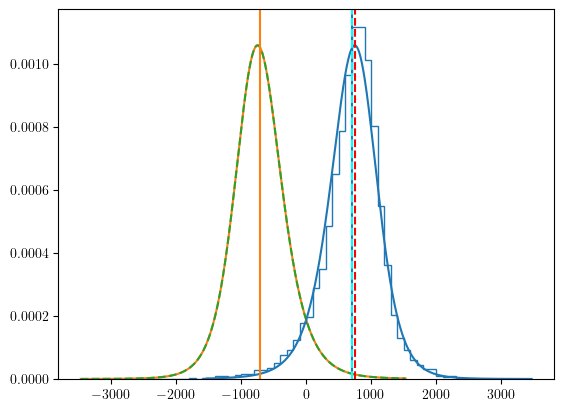

In [28]:
vedges = np.linspace(-2500, 2500, 50+1)
vcens = 0.5*(vedges[1:]+vedges[:-1])

vcens_fine = np.linspace(vedges[0], vedges[-1], 1000)

R_ind = 0
rl_ind = 10

ptest = Pv_R_rlos(vcens_fine, R_cens[R_ind], rlos_cens[rl_ind], Mvirs2[0])
ntest = Pv_R_rlos(vcens_fine, R_cens[R_ind], -rlos_cens[rl_ind], Mvirs2[0])

hflo = a*H*rlos_cens[rl_ind]/h

plt.plot(vcens_fine+hflo, ptest)
plt.plot(vcens_fine-hflo, ntest)
plt.plot(vcens_fine-hflo, np.flip(ptest), ls='--')
hist = plt.hist(data_dict[0][R_ind][rl_ind+60]['vpeclos']+hflo, bins=vedges, density=True, histtype='step', color='C0')

plt.axvline(vlos_mean(R_cens[R_ind], rlos_cens[rl_ind], Mvirs2[0])+hflo, c="C0")
plt.axvline(np.mean(data_dict[0][R_ind][rl_ind+60]['vpeclos'])+hflo, c="cyan", ls='--')
plt.axvline(vcens_fine[np.argmax(ptest)]+hflo, c="red", ls='--')
plt.axvline(-(vlos_mean(R_cens[R_ind], rlos_cens[rl_ind], Mvirs2[0])+hflo), c="C1")

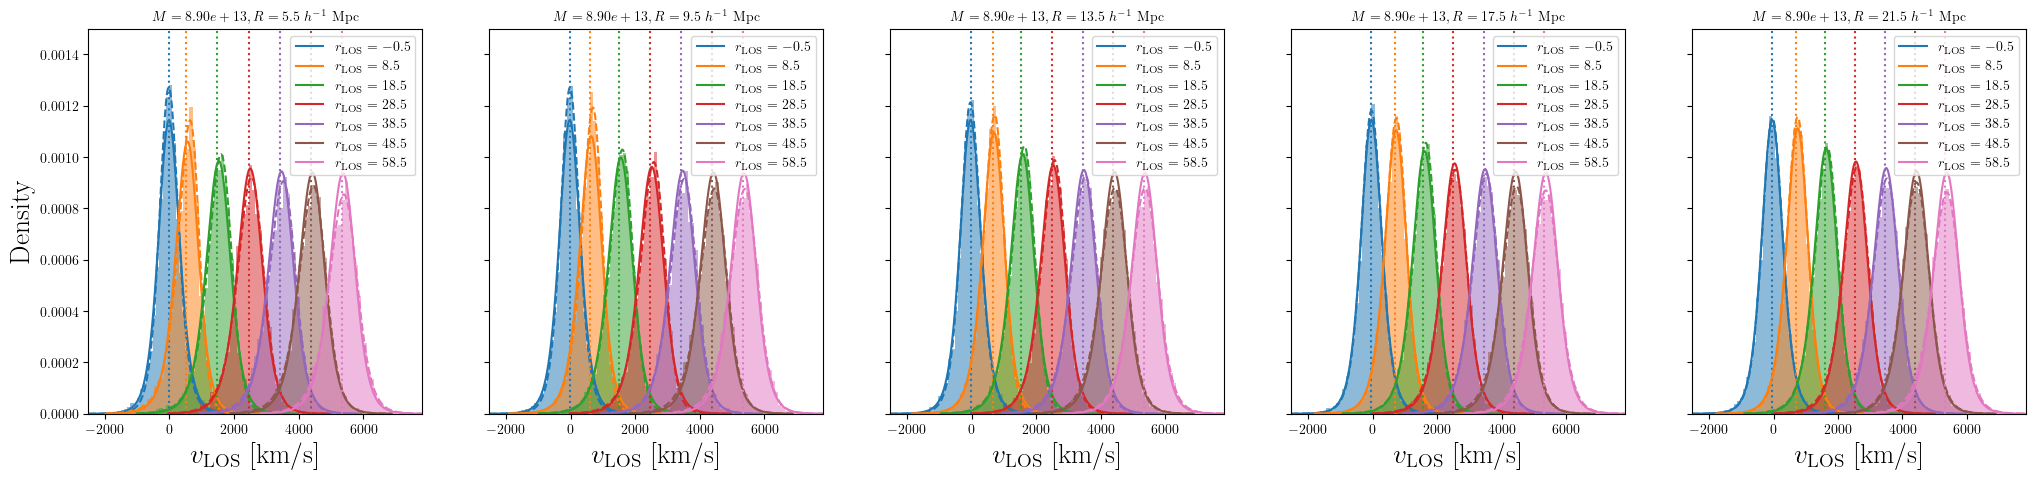

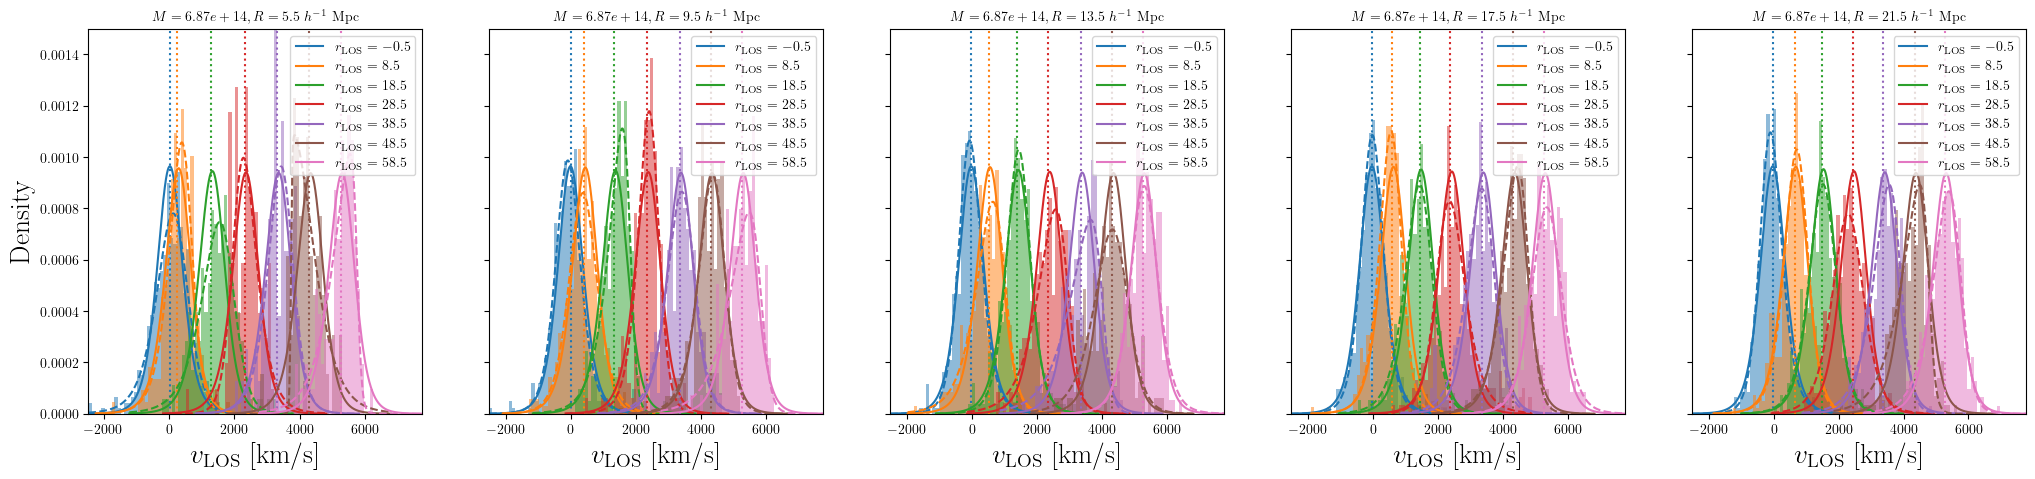

In [106]:

# test fit to P(vlos|R, rlos)
R_inds    = [0, 4, 8, 12, 16]
rlos_inds = [0, 9, 19, 29, 39, 49, 59]

nu=6

for k in range(0, len(Mvirs2), 9):
    
    fig, ax = plt.subplots(1, len(R_inds), figsize=(5*len(R_inds), 5), sharey=True)

    for j in R_inds:
        for i in rlos_inds:

            r = np.sqrt(R_cens[j]**2 + rlos_cens_dual[i+59]**2)
            theta = np.arctan2(rlos_cens_dual[i+59], R_cens[j])
            sin = np.sin(theta)

            mu = RBinterp(np.log10(Mvirs2[k]), r).squeeze()*sin
            peak = mu + a*H*rlos_cens_dual[i+59]/h

            ve = np.linspace(peak-2500, peak+2500, 50+1)
            vc = 0.5*(ve[1:] + ve[:-1])

            test_hist, bins, _ = ax[j//4].hist(data_dict[k][j][i+59]['vphyslos'], bins=ve, density=True, alpha=0.5, color=f'C{i//9}')
            cens = 0.5*(bins[1:] + bins[:-1])
            cens_fine = np.linspace(bins[0], bins[-1], 1000)

            P = Pv_R_rlos(cens_fine-a*H*rlos_cens_dual[i+59]/h, R_cens[j], rlos_cens_dual[i+59], Mvirs2[k], res2.x[:3], res2.x[3:]) #res.x[:3], res.x[3:] 
            #Pv_R_rlos_smooth(cens-a*H*rlos_cens_dual[i+59]/h, R_cens[j], rlos_cens_dual[i+59], Mvirs2[k], res.x)

            ax[j//4].plot(cens_fine, P, c=f'C{i//9}', label=rf'$r_{{\rm LOS}}={rlos_cens_dual[i+59]}$')
            ax[j//4].plot(cens_fine, skewed_t_pdf(cens_fine-a*H*rlos_cens_dual[i+59]/h, STpars[k, j, i, 0], STpars[k, j, i, 1], STpars[k, j, i, 2], nu), c=f'C{i//9}', ls ='--',)


            ax[j//4].axvline(peak, color=f'C{i//9}', ls=':')

            ax[j//4].set_title(rf"$M={Mvirs2[k]:.2e}, R = {R_cens[j]}$ $h^{{-1}}$ Mpc ", fontsize=10)
            ax[j//4].set_xlabel(r"$v_{\rm LOS}$ [km/s]", fontsize=20)
            ax[0].set_ylabel(r"Density", fontsize=20)
            ax[j//4].margins(x=0) 

            #if i == rlos_inds[0]:
            ax[j//4].legend()
            ax[j//4].set_ylim((0, 0.0015))

In [29]:
Nv_R_rlos = np.zeros((len(vcens), len(Mvirs2), len(R_cens), len(rlos_cens)))

for k in range(len(Mvirs2)):
    for j in range(len(R_cens)):
        for i in range(len(rlos_cens)):

            nhist, bins = np.histogram(data_dict[k][j][i+59]['vpeclos'], bins=vedges, density=False)
            Nv_R_rlos[:, k, j, i] = nhist

In [98]:
# re-fit model to histograms
init_pars = np.array([0.00607357, 4.25343725, 0.22794126, -0.03055477,  0.34374933, 16.46892317])

Bounds = [(np.min((0, np.sign(par)*np.inf)), np.max((0, np.sign(par)*np.inf))) for par in init_pars]


def poisson_llh_vec(pars):
    """
    Nv_R shape assumed: (Nv, NR, NM)
    """
    D_pars = pars[:3]
    S_pars = pars[3:]

    # (Nv, NR, NM)
    P   = Pv_R_rlos_vec(vcens, R_cens, rlos_cens, Mvirs2, D_pars, S_pars) 
    dv  = np.diff(vcens)[0]
    # total counts per (R, rlos, M): (1, NR, NM, Nrlos)
    N   = Nv_R_rlos.sum(axis=0, keepdims=True)
    #print(P.shape, N.shape, dv.shape)
    lam = P * dv * N
    log_likelihood = np.sum(scipy.stats.poisson.logpmf(k=Nv_R_rlos, mu=lam))
    return log_likelihood

tlh = poisson_llh_vec(init_pars)
tlh

np.float64(-2029779.7004732306)

In [99]:
# MLE 
res = scipy.optimize.minimize(lambda p: -poisson_llh_vec(p), init_pars, bounds=Bounds, method='nelder-mead')
print("Initial: ", init_pars) 
print("MLE: ", res.x)

Initial:  [ 6.07357000e-03  4.25343725e+00  2.27941260e-01 -3.05547700e-02
  3.43749330e-01  1.64689232e+01]
MLE:  [ 1.58791684e-01  3.18840084e-01  4.26611237e-05 -4.54072437e-02
  3.74932462e-01  1.07860248e+01]


In [101]:
res

       message: Maximum number of function evaluations has been exceeded.
       success: False
        status: 1
           fun: 2007923.8376719987
             x: [ 1.588e-01  3.188e-01  4.266e-05 -4.541e-02  3.749e-01
                  1.079e+01]
           nit: 771
          nfev: 1200
 final_simplex: (array([[ 1.588e-01,  3.188e-01, ...,  3.749e-01,
                         1.079e+01],
                       [ 1.587e-01,  3.198e-01, ...,  3.749e-01,
                         1.079e+01],
                       ...,
                       [ 1.587e-01,  3.194e-01, ...,  3.749e-01,
                         1.079e+01],
                       [ 1.587e-01,  3.187e-01, ...,  3.749e-01,
                         1.079e+01]]), array([ 2.008e+06,  2.008e+06,  2.008e+06,  2.008e+06,
                        2.008e+06,  2.008e+06,  2.008e+06]))

In [102]:
# MLE, again 
res2 = scipy.optimize.minimize(lambda p: -poisson_llh_vec(p), res.x, bounds=Bounds, method='nelder-mead')
print("Initial: ", res.x) 
print("MLE: ", res2.x)

Initial:  [ 1.58791684e-01  3.18840084e-01  4.26611237e-05 -4.54072437e-02
  3.74932462e-01  1.07860248e+01]
MLE:  [ 1.58565530e-01  3.20425113e-01  4.35742317e-05 -4.53981362e-02
  3.74929938e-01  1.07841238e+01]


In [103]:
res2

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2007923.8319691953
             x: [ 1.586e-01  3.204e-01  4.357e-05 -4.540e-02  3.749e-01
                  1.078e+01]
           nit: 73
          nfev: 137
 final_simplex: (array([[ 1.586e-01,  3.204e-01, ...,  3.749e-01,
                         1.078e+01],
                       [ 1.586e-01,  3.204e-01, ...,  3.749e-01,
                         1.078e+01],
                       ...,
                       [ 1.586e-01,  3.205e-01, ...,  3.749e-01,
                         1.078e+01],
                       [ 1.586e-01,  3.204e-01, ...,  3.749e-01,
                         1.078e+01]]), array([ 2.008e+06,  2.008e+06,  2.008e+06,  2.008e+06,
                        2.008e+06,  2.008e+06,  2.008e+06]))

In [30]:
comp_pars = [ 1.58565530e-01,  3.20425113e-01,  4.35742317e-05, 
             -4.53981362e-02,  3.74929938e-01,  1.07841238e+01]

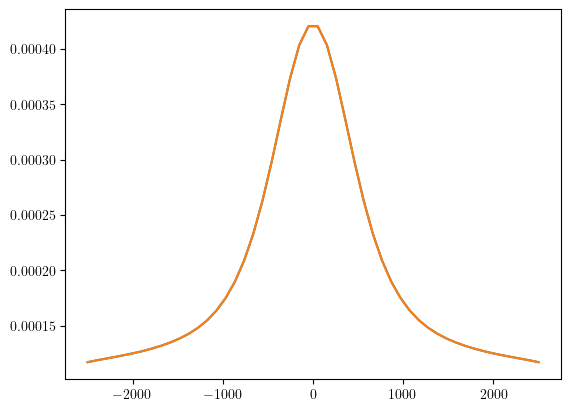

In [77]:
def Pv_R(vphys, R, M):
    rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

    # rlos integration range
    rlos_max = 40
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(2 * rlos_max + 1))
    rlos_vals = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    Pvlos_interp_list = []

    for j, rlos in enumerate(rlos_vals):
        hflo = a * H * rlos / h

        ve = np.linspace(vlos_mean(R, rlos, M)-2500, vlos_mean(R, rlos, M)+2500, 101)
        vc = 0.5 * (ve[1:] + ve[:-1])

        # ── replaced Pv_R_rlos_smooth ──────────────────────────────────────
        Pvlos = Pv_R_rlos(vc, R, rlos, M,)#
        # ──────────────────────────────────────────────────────────────────

        interp_func = interp1d(
            vc + hflo, Pvlos, kind="cubic", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vphys)          # shape: (len(vphys),)
        Pvlos_interp_list.append(interpolated)

    # shape: (len(vphys), len(rlos_vals))
    Pvlos_interp = np.array(Pvlos_interp_list).T

    r3d    = np.sqrt(R**2 + rlos_vals**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1) #dens_interp(np.log10(M), r3d, grid=False).squeeze() #
    #print(weight.shape)
    integrand = Pvlos_interp * weight[np.newaxis, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    return P_out / np.sum(P_out * np.diff(vphys)[0])

vcens = np.linspace(-2500, 2500, 50)

test = Pv_R(vcens, R_cens[0], Mvirs2[0])

plt.plot(vcens, test)
plt.plot(vcens, np.flip(test))
#plt.plot(vcens, 0.5*(test+np.flip(test)))

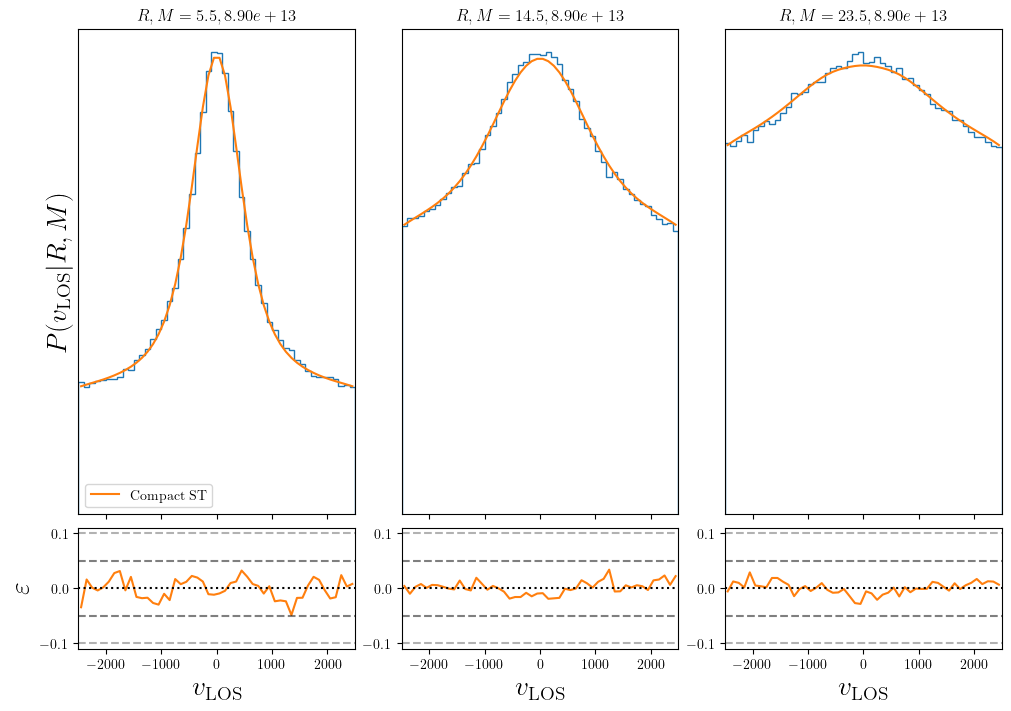

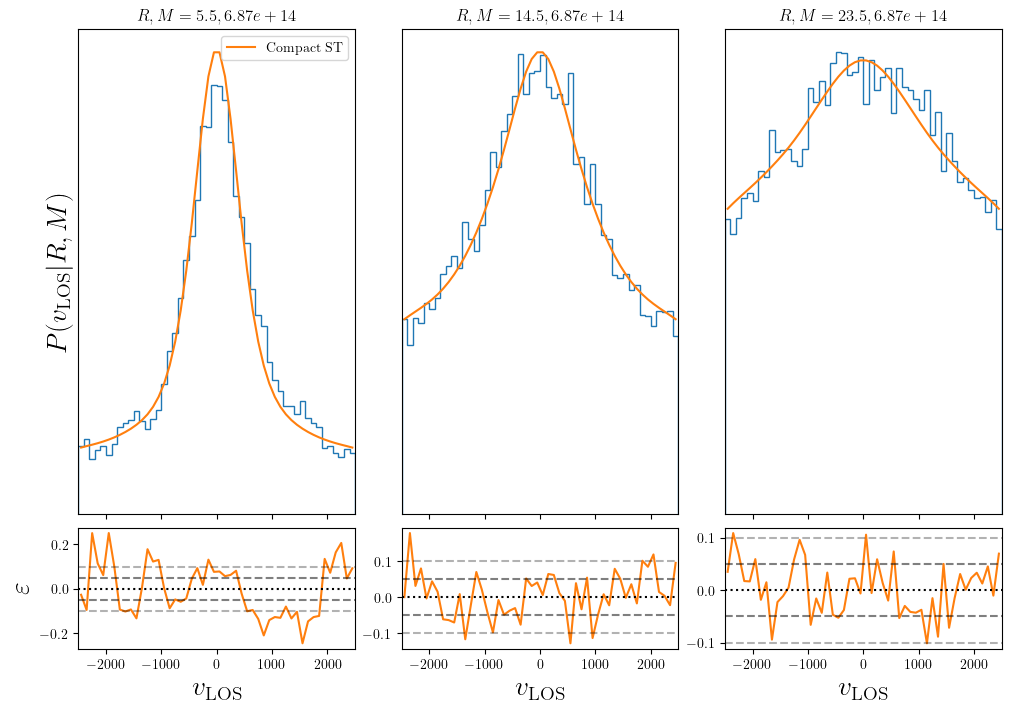

In [78]:
# validate fits on P(v|R, M)
vedges = np.linspace(-2500, 2500, 50+1)
vcens = 0.5*(vedges[1:]+vedges[:-1])

for k in range(0, len(Mvirs2), 9):
    fig, ax = plt.subplots(2, len(R_cens)//7, figsize=(10, 7), layout='constrained', sharex=True, gridspec_kw={'height_ratios': [4, 1]})
    for j in range(0, len(R_cens), 9):
        index = j + k*len(R_cens)

        vphys = np.concatenate([rlos_dict['vphyslos'] for rlos_idx, rlos_dict in data_dict[k][j].items()])
        
        hist, bins, _ = ax[0, j//7].hist(vphys, bins=vedges, density=True, histtype='step') #np.concatenate((vphys,-vphys))

        #hist, bins, _ = ax[0, j//7].hist(vphyslos[index], range=[-2500, 2500], bins='auto', density=True, histtype='step')
        cent = 0.5*(bins[1:] + bins[:-1])

        # ax[0, j//7].plot(cent, P_R_ind_free(cent, j, k), label='Free', c='C1')
        # ax[0, j//7].plot(cent, P_R_ind_fix(cent, j, k), label='Fixed peak', ls='--', c='C1')

        model = 0.5*(Pv_R(vcens, R_cens[j], Mvirs2[k])+np.flip(Pv_R(vcens, R_cens[j], Mvirs2[k])))

        ax[0, j//7].plot(cent, model, label='Compact ST', c='C1')
        ax[1, j//7].plot(cent, (model-hist)/hist, c='C1')
        ax[1, j//7].axhline(0, ls=':', c='k')
        ax[1, j//7].axhline(0.05, ls='--', c='k', alpha=0.5)
        ax[1, j//7].axhline(-0.05, ls='--', c='k', alpha=0.5)
        ax[1, j//7].axhline(0.1, ls='--', c='k', alpha=0.3)
        ax[1, j//7].axhline(-0.1, ls='--', c='k', alpha=0.3)

        ax[1, j//7].set_xlabel(r"$v_{\rm LOS}$", fontsize=20)
        ax[0, j//7].set_yticks([])
        ax[0, j//7].margins(x=0)
        ax[0, j//7].set_title(rf"$R, M = {R_cens[j]}, {Mvirs2[k]:.2e}$")

    ax[0, 0].legend()
    ax[0, 0].set_ylabel(r"$P(v_{\rm LOS}|R, M)$", fontsize=20)
    ax[1, 0].set_ylabel(r"$\varepsilon$")



In [63]:
Nv_R = np.zeros((len(Mvirs2), len(R_cens), len(vcens)))

for k in range(len(Mvirs2)):
    for j in range(len(R_cens)):

        vphys = np.concatenate([rlos_dict['vphyslos'] for rlos_idx, rlos_dict in data_dict[k][j].items()])

        nphys, _ = np.histogram(vphys, bins=vedges, density=False)

        Nv_R[k, j] = nphys

In [64]:
def RG_llh_ind(pars, data, r_ind):
    M, s = pars 

    M_p = 1e14

    dv = (vedges[-1]-vedges[0])/(len(vedges)-1)

    N_avg = np.sum(data) * Pv_R(vcens, R_cens[r_ind], M*M_p) * dv

    sigmasq = N_avg + s**2 * N_avg**2

    chisq = ((data) - N_avg)**2 / sigmasq  

    #print(chisq, sigmasq, N_avg)

    return - 0.5 * np.nansum(chisq + np.log(sigmasq))

In [70]:
Mvirs2[-1]/1e14

np.float64(6.8732)

In [85]:
test_ms = np.logspace(np.log10(mbins2[0]/1e14), np.log10(mbins2[-1]/1e14), 30)
llh_prof = np.array([[-RG_llh_ind([p, 0], Nv_R[0, i], i) for i in range(len(R_cens))] for p in test_ms])

In [86]:
llh_prof.shape

(30, 25)

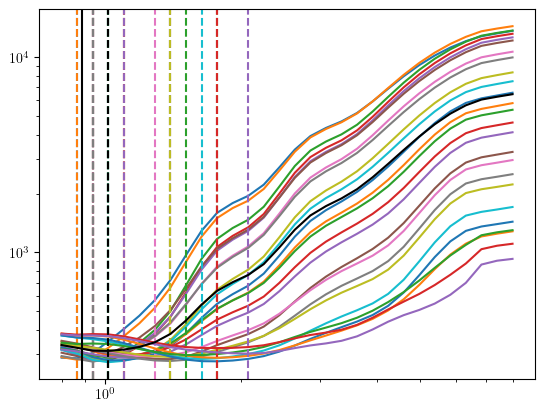

In [90]:
for i in range(llh_prof.shape[1]):
    plt.loglog(test_ms, llh_prof[:, i])
    plt.axvline(test_ms[np.argmin(llh_prof[:, i])], c=f'C{i}', ls='--')

plt.plot(test_ms, np.mean(llh_prof, axis=1), c='k', ls='-')
plt.axvline(test_ms[np.argmin(np.mean(llh_prof, axis=1))], c='k', ls='--')
plt.axvline(Mvirs2[0]/1e14, c='k')

In [91]:
# MLE 
soln = scipy.optimize.minimize(lambda p: -RG_llh_ind(p, Nv_R[0, 0], 0), [Mvirs2[0]/1e14, 0.01], method='nelder-mead', )
print("Initial: ", [Mvirs2[0]/1e14, 0.01]) 
print("MLE: ", soln.x) 

Initial:  [np.float64(0.89001), 0.01]
MLE:  [0.85061521 0.01362359]


In [95]:
pars = np.zeros((len(Mvirs2), len(R_cens), 2))
#errs = np.zeros((len(Mvirs2), len(R_cens), 2))


for k in range(len(Mvirs2)):
    for i in range(len(R_cens)):
        p_init = [Mvirs2[k]/1e14, 0.01]

        soln = scipy.optimize.minimize(lambda p: -RG_llh_ind(p, Nv_R[k, i], i), p_init, 
                                    #bounds = [(0.5, 12), (-0.1, 0.1)],#, (0, np.inf), (0, np.inf)], 
                                    method='nelder-mead', 
                                    )
        print("Initial: ",p_init) 
        print("MLE: ", soln.x) 
        print(soln.message)

        pars[k, i] = soln.x

Initial:  [np.float64(0.89001), 0.01]
MLE:  [0.85061521 0.01362359]
Optimization terminated successfully.
Initial:  [np.float64(0.89001), 0.01]
MLE:  [0.89019861 0.01118231]
Optimization terminated successfully.
Initial:  [np.float64(0.89001), 0.01]
MLE:  [0.95139207 0.00908308]
Optimization terminated successfully.
Initial:  [np.float64(0.89001), 0.01]
MLE:  [0.9653728  0.00805121]
Optimization terminated successfully.
Initial:  [np.float64(0.89001), 0.01]
MLE:  [0.95503566 0.00747301]
Optimization terminated successfully.
Initial:  [np.float64(0.89001), 0.01]
MLE:  [0.92601709 0.00869633]
Optimization terminated successfully.
Initial:  [np.float64(0.89001), 0.01]
MLE:  [0.9664033 0.0091486]
Optimization terminated successfully.
Initial:  [np.float64(0.89001), 0.01]
MLE:  [0.9363031 0.0056665]
Optimization terminated successfully.
Initial:  [np.float64(0.89001), 0.01]
MLE:  [1.0178871  0.00513734]
Optimization terminated successfully.
Initial:  [np.float64(0.89001), 0.01]
MLE:  [1.015

ValueError: `x` array is all-nan

In [112]:
k=9
for i in range(len(R_cens)):
    p_init = [Mvirs2[k]/1e14, 0.01]

    soln = scipy.optimize.minimize(lambda p: -RG_llh_ind(p, Nv_R[k, i], i), p_init, 
                                #bounds = [(0.5, 12), (-0.1, 0.1)],#, (0, np.inf), (0, np.inf)], 
                                method='nelder-mead', 
                                )
    print("Initial: ",p_init) 
    print("MLE: ", soln.x) 
    print(soln.message)

    pars[k, i] = soln.x

Initial:  [np.float64(6.8732), 0.01]
MLE:  [13.40067813  0.08060123]
Optimization terminated successfully.
Initial:  [np.float64(6.8732), 0.01]
MLE:  [5.42163053 0.05024437]
Optimization terminated successfully.
Initial:  [np.float64(6.8732), 0.01]
MLE:  [6.14539454 0.02752766]
Optimization terminated successfully.
Initial:  [np.float64(6.8732), 0.01]
MLE:  [13.6297278   0.02204624]
Optimization terminated successfully.
Initial:  [np.float64(6.8732), 0.01]
MLE:  [7.73282297 0.01750673]
Optimization terminated successfully.
Initial:  [np.float64(6.8732), 0.01]
MLE:  [9.26769623 0.03291814]
Optimization terminated successfully.
Initial:  [np.float64(6.8732), 0.01]
MLE:  [11.98972223  0.0461603 ]
Optimization terminated successfully.
Initial:  [np.float64(6.8732), 0.01]
MLE:  [13.01700443  0.02692881]
Optimization terminated successfully.
Initial:  [np.float64(6.8732), 0.01]
MLE:  [13.52676947  0.02596974]
Optimization terminated successfully.
Initial:  [np.float64(6.8732), 0.01]
MLE:  [2

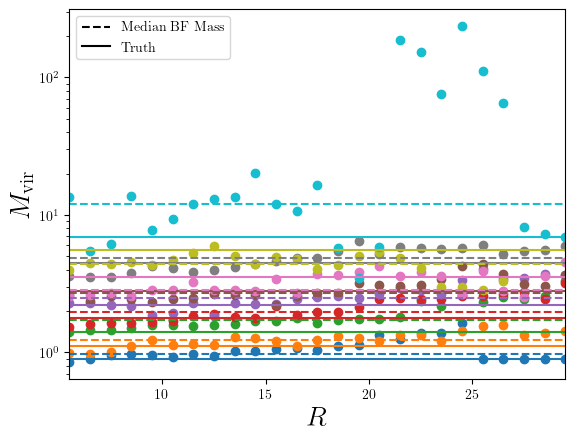

In [113]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots()

mvirs = Mvirs2/1e14

for k in range(len(mvirs)):
    ax.scatter(R_cens, pars[k, :, 0], c=f'C{str(k)}')
    #ax.errorbar(R_cens, pars[k, :, 0], np.abs(err_mass_ind[k, :, 1]), fmt='o', c=f'C{str(k)}')    
    ax.axhline(np.median(pars[k, :, 0]), ls='--', c=f'C{str(k)}')
    ax.axhline(mvirs[k], ls='-', c=f'C{str(k)}', )


marker_1 = Line2D(
    [0], [0],
    color='k',          
    marker='none',
    linestyle='--',
    label='Median BF Mass', 
)

marker_2 = Line2D(
    [0], [0],
    color='k',          
    marker='none',
    linestyle='-',
    label='Truth'
)

ax.set_xlabel(r'$R$', fontsize=20)
ax.set_ylabel(r'$M_{\rm vir}$', fontsize=20)
ax.set_yscale('log')
ax.margins(x=0)
#ax.set_title('Indiv. Fit to '+fit_name, fontsize=25)
plt.legend(handles=[marker_1, marker_2], fontsize=10)


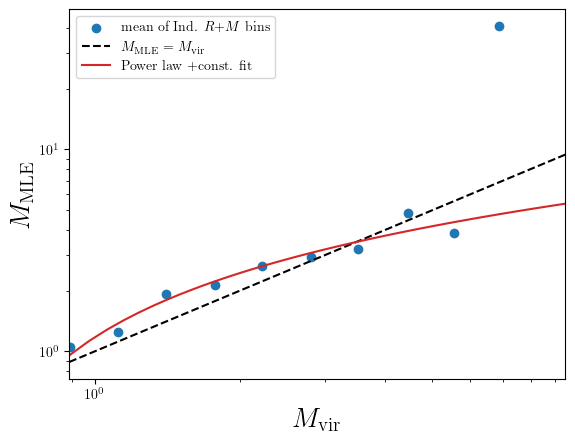

In [119]:
ms = np.linspace(Mvirs[0]/1e14-0.1, Mvirs[-1]/1e14+0.5, 100)

p, c = curve_fit(plawc, mvirs[:-1], np.mean(pars[:-1, :, 0], axis=-1), maxfev=10_000)
plt.scatter(mvirs, np.mean(pars[:, :, 0], axis=-1), label='mean of Ind. $R$+$M$ bins')
plt.plot(ms, line(ms, 1, 0), c='k', ls='--', label=r'$M_{\rm MLE} = M_{\rm vir}$')
plt.plot(ms, plawc(ms, *p), c='C3', ls='-', label='Power law +const. fit')
plt.margins(x=0)
plt.ylabel(r'$M_{\rm MLE}$', fontsize=20)
plt.xlabel(r'$M_{\rm vir}$', fontsize=20)
plt.legend(fontsize=10)
plt.yscale('log')
plt.xscale('log')

Text(0, 0.5, '$\\sigma_{\\rm inht}^2$')

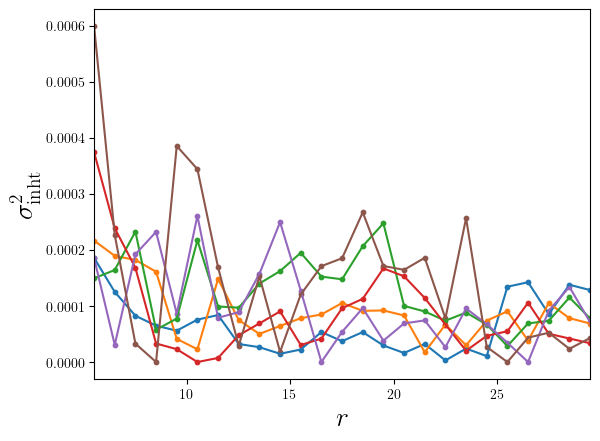

In [103]:
inht_pars = np.zeros((6, 3))
inht_errs = np.zeros(inht_pars.shape)

for k in range(6):
    plt.scatter(R_cens, pars[k, :, 1]**2, s=10)
    plt.plot(R_cens, pars[k, :, 1]**2)
    #plt.errorbar(R_cens, pars[k, :, 1], err_mass_ind_RG[k, :, 1], fmt='o')

    # p, c = curve_fit(plawc, R_cens/15, pars[k, :, 1], maxfev=1_000)
    # plt.plot(R_cens, plawc(R_cens/15, p[0], p[1], p[2]), c=f'C{str(k)}')
    # p, c = curve_fit(erf, R_cens/15, pars[k, :, 1]**2, maxfev=2_000)
    # plt.plot(R_cens, erf(R_cens/15, p[0], p[1], p[2]), c=f'C{str(k)}')
    
    # inht_pars[k, :] = p
    # inht_errs[k, :] = np.sqrt(np.diag(c))

plt.margins(x=0)
#plt.ylim((0, 0.12))
plt.xlabel(r'$r$', fontsize=20)
plt.ylabel(r'$\sigma_{\rm inht}^2$', fontsize=20)

# marker_1 = Line2D([0], [0], color='k', marker='none', linestyle='-',  label=r'$A \ [\mathrm{erf}\left(\frac{r/r_p - m}{\sigma}\right)+1]$',)

# plt.legend(handles=[marker_1], fontsize=15) 

(0.0, 50.0)

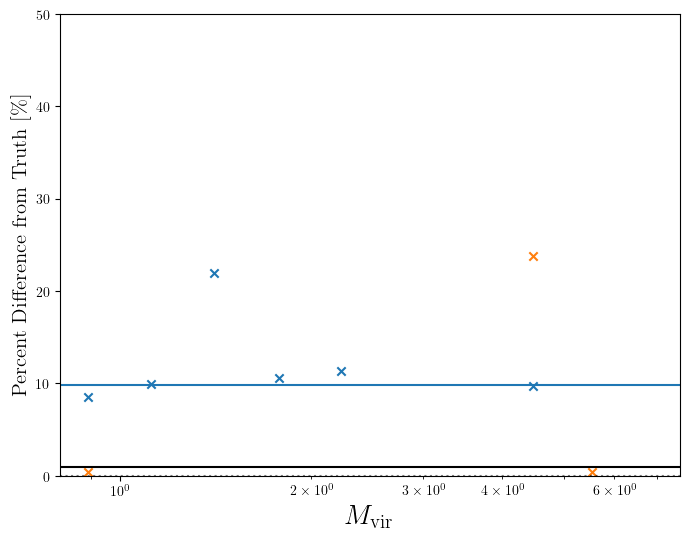

In [132]:
fig, ax = plt.subplots(figsize=(8,6))


#ax.scatter(mvirs, ((par_mass_ind[j, :, 0]-mvirs)/mvirs)*100, marker='x')
#ax.axhline(np.median(np.abs((par_mass_ind[j, :, 0]-mvirs)/mvirs))*100, label=r'All $R | M$', c='C1') 
mpc = plawc(mvirs, *p)
#ml = line(mvirs, p[0], p[1])

ax.scatter(mvirs, 100*((np.median(pars[:, :, 0], axis=1)-mvirs))/mvirs, marker='x')
ax.scatter(mvirs, 100*((np.median(pars[:, :, 0], axis=1)-mpc))/mpc, marker='x', c='C1')
#ax.scatter(mvirs, ((pars[:-1]-ml)/err_mass_sim[:-1])/100, marker='x')

#print(((pars[:-1]-mpc)/mpc)*100)
#print(((pars[:-1]-ml)/ml)*100)
ax.axhline(np.median((np.median(pars[:, :, 0], axis=1)-mvirs)/mvirs)*100, label=r'All $R+M$ simult. avg PD', c='C0') 
ax.axhline(np.median(((np.median(pars[:, :, 0], axis=1)-mpc))/mpc)*100, label=r'All $R+M$ simult. avg PD', c='C1') 

ax.axhline(1, c='k') 

ax.axhline(0.0, c='k', ls=':', alpha=0.5)
ax.set_xlabel(r"$M_{\rm vir}$", fontsize=20) 
ax.set_ylabel(r"Percent Difference from Truth $[\%]$", fontsize=15) 
ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_ylim((0, 50))


